In [1]:
# !pip install roboflow

In [2]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="p5A1Dc89ug39Uh25pdHW")
# project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
# version = project.version(14)
# dataset = version.download("darknet")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
import torch
print(torch.version.cuda)  # should be 13.x
print(torch.cuda.is_available())  # should be True
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

11.3
True
0
Tesla P100-PCIE-16GB


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os

dataset_path = "./rock-paper-scissors-14"
for split in ["train", "valid"]:
    label_dir = os.path.join(dataset_path, split)
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for i, line in enumerate(f):
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(parts[0])
                if cls >= 3 or cls < 0:
                    print(f"BAD LABEL in {fname} line {i}: class={cls}")

In [ ]:
from super_gradients.training.datasets import YoloDarknetFormatDetectionDataset

dataset_path = "./rock-paper-scissors-14"

train_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="train",
    labels_dir="train",
    classes=["Rock", "Paper", "Scissors"],
    show_all_warnings=True
)

val_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="valid",
    labels_dir="valid",
    classes=["Rock", "Paper", "Scissors"]
)

The console stream is logged into /root/sg_logs/console.log


[2026-03-05 03:55:27] INFO - crash_tips_setup.py - Crash tips is enabled. You can set your environment variable to CRASH_HANDLER=FALSE to disable it


[WARNING]No module named 'pycocotools'


[2026-03-05 03:55:30] INFO - env_sanity_check.py - Library check is not supported when super_gradients installed through "git+https://github.com/..." command
[2026-03-05 03:55:31] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 6455/6455 [00:01<00:00, 5259.25it/s]
[2026-03-05 03:55:32] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.


Indexing dataset annotations: 100%|██████████| 576/576 [00:00<00:00, 5920.50it/s]


The dataset was returning each sample's labels as [x1, y1, x2, y2, class], but YOLOX loss expects targets in [batch_idx, class, cx, cy, w, h] format. Three things were wrong:

Class was in the last column — we were accidentally reading x1 as the class, which gave huge values like 305, 268 etc. that were way out of range for F.one_hot(..., num_classes=3), triggering the CUDA assert.
No batch index — the loss needs to know which image each box belongs to since all boxes across the batch are concatenated into one tensor. We prepended i (the loop index) for each sample.
Corner format → center format — the dataset gave [x1, y1, x2, y2] (top-left/bottom-right corners) but YOLOX expects [cx, cy, w, h] (center + dimensions), so we converted them.

In [7]:
from torch.utils.data import DataLoader
from super_gradients.training.utils.collate_fn import DetectionCollateFN
import numpy as np
import torch
def yolox_collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack([torch.from_numpy(np.array(img)).permute(2, 0, 1).float() for img in imgs], 0)
    padded_targets = []
    for i, t in enumerate(targets):
        t = torch.as_tensor(t, dtype=torch.float32)
        if t.shape[0] > 0:
            # Dataset gives [x1, y1, x2, y2, class] — class is index 4 (5-col, no batch idx yet)
            cls = t[:, 4:5]                          # class is last column
            x1, y1, x2, y2 = t[:, 0], t[:, 1], t[:, 2], t[:, 3]
            cx = ((x1 + x2) / 2).unsqueeze(1)
            cy = ((y1 + y2) / 2).unsqueeze(1)
            w  = (x2 - x1).unsqueeze(1)
            h  = (y2 - y1).unsqueeze(1)
            batch_col = torch.full((t.shape[0], 1), i, dtype=torch.float32)
            # Final: [batch_idx, class, cx, cy, w, h]
            padded_targets.append(torch.cat([batch_col, cls, cx, cy, w, h], dim=1))
    targets = torch.cat(padded_targets, 0) if padded_targets else torch.zeros((0, 6))
    return imgs, targets
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=yolox_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=yolox_collate_fn)

In [8]:
from super_gradients.training import models
from super_gradients.training import Trainer
import torch
from torch.utils.data import DataLoader
from super_gradients.common.object_names import Models

trainer = Trainer(experiment_name="yolon", ckpt_root_dir="./checkpoints")

model = models.get(
    Models.YOLOX_N,
    num_classes=3,
    checkpoint_path="/app/models/yolox_nano.pth",
    strict_load=False
)
model.num_classes

/usr/local/lib/python3.8/dist-packages/super_gradients/common/deprecate.py:279: DeprecationWarning: Parameter `arch_params.channels_in` is deprecated since version `3.3.0` and will be removed in version `4.0.0`.
Please update your code to use the `arch_params.in_channels` instead of `arch_params.channels_in`.
  warnings.warn(message, DeprecationWarning)


[2026-03-05 03:55:32] INFO - checkpoint_utils.py - Successfully loaded model weights from /app/models/yolox_nano.pth checkpoint.


3

In [20]:
from super_gradients.training import training_hyperparams
train_params = training_hyperparams.get('coco2017_yolox')

train_params['max_epochs'] = 30
train_params['lr_warmup_epochs'] = 0
train_params['lr_cooldown_epochs'] = 0
train_params['criterion_params']['num_classes'] = 3
train_params['average_best_models'] = False
train_params['initial_lr'] = 0.0005
train_params['cosine_final_lr_ratio'] = 0.9
train_params['mixed_precision'] = False

In [ ]:
# train_params['max_epochs'] = 80
# train_params['initial_lr'] = 0.001
# train_params['cosine_final_lr_ratio'] = 0.05
# train_params['lr_warmup_epochs'] = 3
# train_params['lr_cooldown_epochs'] = 10
# train_params['criterion_params']['num_classes'] = 3
# train_params['average_best_models'] = True
# train_params['mixed_precision'] = True
# train_params['ema'] = True
# train_params['sync_bn'] = False

In [ ]:
trainer.train(model=model, training_params=train_params, train_loader=train_loader, valid_loader=val_loader)

[2026-03-05 04:15:33] WARNING - sg_trainer.py - Train dataset size % batch_size != 0 and drop_last=False, this might result in smaller last batch.
[2026-03-05 04:15:33] INFO - sg_trainer.py - Starting a new run with `run_id=RUN_20260305_041533_126333`
[2026-03-05 04:15:33] INFO - sg_trainer.py - Checkpoints directory: ./checkpoints/yolon/RUN_20260305_041533_126333
[2026-03-05 04:15:33] INFO - sg_trainer.py - Using EMA with params {'decay': 0.9999, 'decay_type': 'exp', 'beta': 15}
/usr/local/lib/python3.8/dist-packages/super_gradients/training/utils/optimizer_utils.py:108: DeprecationWarning: initialize_param_groups and update_param_groups usages are deprecated since 3.4.0, will be removed in 3.5.0 and have no effect. 
 Assign different learning rates by passing a mapping of layer name prefixes to lr values through initial_lr training hyperparameter (i.e initial_lr={'backbone': 0.01, 'default':0.1})
  warnings.warn(


The console stream is now moved to ./checkpoints/yolon/RUN_20260305_041533_126333/console_Mar05_04_15_33.txt


[2026-03-05 04:15:33] INFO - sg_trainer_utils.py - TRAINING PARAMETERS:
    - Mode:                         Single GPU
    - Number of GPUs:               1          (1 available on the machine)
    - Full dataset size:            3939       (len(train_set))
    - Batch size per GPU:           8          (batch_size)
    - Batch Accumulate:             1          (batch_accumulate)
    - Total batch size:             8          (num_gpus * batch_size)
    - Effective Batch size:         8          (num_gpus * batch_size * batch_accumulate)
    - Iterations per epoch:         493        (len(train_loader))
    - Gradient updates per epoch:   493        (len(train_loader) / batch_accumulate)
    - Model: YoloX_N  (897.14K parameters, 897.14K optimized)
    - Learning Rates and Weight Decays:
      - default: (897.14K parameters). LR: 0.0005 (897.14K parameters) WD: 0.0, (15.42K parameters), WD: 0.0005, (881.73K parameters)

[2026-03-05 04:15:33] INFO - sg_trainer.py - Started training fo

SUMMARY OF EPOCH 0
├── Train
│   ├── Yoloxdetectionloss/iou = 0.6155
│   ├── Yoloxdetectionloss/obj = 3.1292
│   ├── Yoloxdetectionloss/cls = 1.2594
│   ├── Yoloxdetectionloss/l1 = 0.0
│   ├── Yoloxdetectionloss/num_fg = 4.9731
│   └── Yoloxdetectionloss/loss = 7.466
└── Validation
    ├── Yoloxdetectionloss/iou = 0.5963
    ├── Yoloxdetectionloss/obj = 3.1786
    ├── Yoloxdetectionloss/cls = 1.2538
    ├── Yoloxdetectionloss/l1 = 0.0
    ├── Yoloxdetectionloss/num_fg = 5.2056
    ├── Yoloxdetectionloss/loss = 7.4139
    ├── Precision@0.50:0.95 = 0.0528
    ├── Recall@0.50:0.95 = 0.195
    ├── Map@0.50:0.95 = 0.0741
    ├── F1@0.50:0.95 = 0.083
    └── Best_score_threshold = 0.2



Validating epoch 1: 100%|██████████| 43/43 [00:06<00:00,  6.23it/s]
[2026-03-05 04:20:52] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260305_041533_126333/ckpt_best.pth
[2026-03-05 04:20:52] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.07884015887975693
Train epoch 2:   0%|          | 0/493 [00:00<?, ?it/s]

...

Validating epoch 28: 100%|██████████| 43/43 [00:06<00:00,  6.72it/s]
[2026-03-05 05:31:59] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260305_041533_126333/ckpt_best.pth
[2026-03-05 05:31:59] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.37630340456962585
Train epoch 29:   0%|          | 0/493 [00:00<?, ?it/s]

SUMMARY OF EPOCH 28
├── Train
│   ├── Yoloxdetectionloss/iou = 0.3841
│   │   ├── Epoch N-1      = 0.388  (↘ -0.0039)
│   │   └── Best until now = 0.388  (↘ -0.0039)
│   ├── Yoloxdetectionloss/obj = 0.8277
│   │   ├── Epoch N-1      = 0.8497 (↘ -0.022)
│   │   └── Best until now = 0.8497 (↘ -0.022)
│   ├── Yoloxdetectionloss/cls = 0.6099
│   │   ├── Epoch N-1      = 0.6162 (↘ -0.0063)
│   │   └── Best until now = 0.6162 (↘ -0.0063)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.2918
│   │   ├── Epoch N-1      = 7.2702 (↗ 0.0216)
│   │   └── Best until now = 4.9731 (↗ 2.3187)
│   └── Yoloxdetectionloss/loss = 3.358
│       ├── Epoch N-1      = 3.406  (↘ -0.048)
│       └── Best until now = 3.406  (↘ -0.048)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.4387
    │   ├── Epoch N-1      = 0.4402 (↘ -0.0014)
    │   └── Best until now = 0.4402 (↘ -0.0014)
    ├── Yoloxdetec

Validating epoch 29: 100%|██████████| 43/43 [00:06<00:00,  6.63it/s]


[2026-03-05 05:34:34] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260305_041533_126333/ckpt_best.pth
[2026-03-05 05:34:34] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.37792670726776123
[2026-03-05 05:34:34] INFO - base_sg_logger.py - [CLEANUP] - Successfully stopped system monitoring process


SUMMARY OF EPOCH 29
├── Train
│   ├── Yoloxdetectionloss/iou = 0.3769
│   │   ├── Epoch N-1      = 0.3841 (↘ -0.0071)
│   │   └── Best until now = 0.3841 (↘ -0.0071)
│   ├── Yoloxdetectionloss/obj = 0.7877
│   │   ├── Epoch N-1      = 0.8277 (↘ -0.04)
│   │   └── Best until now = 0.8277 (↘ -0.04)
│   ├── Yoloxdetectionloss/cls = 0.5897
│   │   ├── Epoch N-1      = 0.6099 (↘ -0.0202)
│   │   └── Best until now = 0.6099 (↘ -0.0202)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.3415
│   │   ├── Epoch N-1      = 7.2918 (↗ 0.0497)
│   │   └── Best until now = 4.9731 (↗ 2.3684)
│   └── Yoloxdetectionloss/loss = 3.2621
│       ├── Epoch N-1      = 3.358  (↘ -0.0959)
│       └── Best until now = 3.358  (↘ -0.0959)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.4372
    │   ├── Epoch N-1      = 0.4387 (↘ -0.0015)
    │   └── Best until now = 0.4387 (↘ -0.0015)
    ├── Yoloxdete

[2026-03-05 05:39:48] INFO - pipelines.py - Fusing some of the model's layers. If this takes too much memory, you can deactivate it by setting `fuse_model=False`


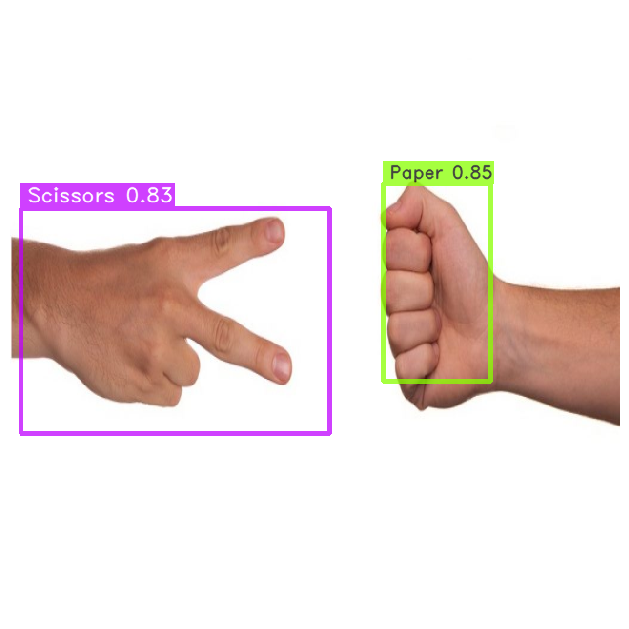

In [37]:
import cv2
import requests
import numpy as np
url = 'https://www.asianscientist.com/wp-content/uploads/bfi_thumb/20170815-rock-scissors-pixabay-34f3h8kx0ucail5dbcp8n4.jpg'
# url='https://bathroomreader.com/wp-content/uploads/2017/11/Rock-Paper-Scissors-1.jpg'
img_array = np.asarray(bytearray(requests.get(url).content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))  # must be multiple of 32

prediction = model.predict(img, conf=0.7)
prediction.show()

In [41]:
export_result = model.export(
    output="../models/yolox_n_rps.onnx",
    input_image_shape=(640, 640),
    onnx_export_kwargs={"opset_version": 11}
)

print(export_result)

/usr/local/lib/python3.8/dist-packages/super_gradients/training/models/detection_models/yolo_base.py:270: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.grid[i].shape[2:4] != output.shape[2:4]:
/usr/local/lib/python3.8/dist-packages/onnx_graphsurgeon/importers/onnx_importer.py:87: DeprecationWarning: `mapping.TENSOR_TYPE_TO_NP_TYPE` is now deprecated and will be removed in a future release.To silence this warning, please use `helper.tensor_dtype_to_np_dtype` instead.
  return onnx.mapping.TENSOR_TYPE_TO_NP_TYPE[onnx_type]
/usr/local/lib/python3.8/dist-packages/torch/onnx/symbolic_opset9.py:2905: UserWarning: Exporting aten::index operator of advanced indexing in opset 11 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat,

Model exported successfully to ../models/yolox_n_rps.onnx
Model expects input image of shape [1, 3, 640, 640]
Input image dtype is torch.uint8
Exported model already contains preprocessing (normalization) step, so you don't need to do it manually.
Preprocessing steps to be applied to input image are:
Sequential(
  (0): CastTensorTo(dtype=torch.float32)
  (1): ChannelSelect(channels_indexes=tensor([2, 1, 0], device='cuda:0'))
)

Exported model contains postprocessing (NMS) step with the following parameters:
    num_pre_nms_predictions=1000
    max_predictions_per_image=1000
    nms_threshold=0.65
    confidence_threshold=0.5
    output_predictions_format=batch

Exported model is in ONNX format and can be used with ONNXRuntime
To run inference with ONNXRuntime, please use the following code snippet:

    import onnxruntime
    import numpy as np
    session = onnxruntime.InferenceSession("../models/yolox_n_rps.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    input